# 5.1	Baseline GA vs Greedy (RQ1 and RQ2)

In [12]:
%load_ext autoreload
%autoreload 2

In [13]:
folder = 'outputs/runs/'

In [31]:
from utils.comparison_metrics import (
    build_results_table,
    extract_results,
    format_results_table,
    extract_cohens_d,
    calculate_poa
)
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [15]:
baseline_files = {
    'Grid':       f'{folder}grid_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Moderate':   f'{folder}moderate_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Falsewalking_Falsedelay_1compliance.pkl',
}

In [16]:
from utils.environment import Environment

grid = Environment('grid-like_topology')
moderate = Environment('moderate-complexity_topology')
bottleneck = Environment('bottleneck-constrained_topology')

In [17]:
graphs = {
    'Grid': grid.graph, 'Moderate': moderate.graph, 'Bottleneck': bottleneck.graph
}

positions = {
    'Grid': grid.pos, 'Moderate': moderate.pos, 'Bottleneck': bottleneck.pos
}


In [18]:
results = extract_results(baseline_files['Grid'])
print(f'Params: {results['ga']['params']}')   # {'walking': False, 'delay_start': False, ...}

Params: {'congestion': True, 'walking': False, 'delay_start': False, 'compliance': 1, 'fitness': 'max-median', 'alpha': 0.8}


In [19]:
df = build_results_table(baseline_files)
formatted = format_results_table(df)
formatted

GA                                    Greedy  \
City                    Bottleneck          Grid      Moderate    Bottleneck   
Metric                                                                         
Average time          21.12 ± 0.16  10.32 ± 0.25  10.83 ± 0.26  19.50 ± 0.00   
Avg Congestion delay   8.99 ± 0.05   2.25 ± 0.09   2.35 ± 0.12   8.98 ± 0.05   
Avg Path Efficiency    1.06 ± 0.01   1.18 ± 0.03   1.11 ± 0.02   1.00 ± 0.00   
Avg path length       12.14 ± 0.18   8.07 ± 0.22   8.48 ± 0.18  10.52 ± 0.05   
Exit utilisation       0.28 ± 0.03   0.08 ± 0.02   0.10 ± 0.04   0.18 ± 0.05   
Total time            30.10 ± 0.30  15.60 ± 0.66  15.30 ± 0.46  29.00 ± 0.00   

                                                          p                   
City                          Grid      Moderate Bottleneck    Grid Moderate  
Metric                                                                        
Average time           7.52 ± 0.16  10.02 ± 0.03     0.002*  0.002*   0.002*  
Avg Congestion delay   2.52 ± 0.16   4.02 ± 0.05      1.000  0.002*   0.002*  
Avg Path Efficiency    1.00 ± 0.00   1.00 ± 0.00     0.002*  0.002*   0.002*  
Avg path length        5.00 ± 0.00   6.00 ± 0.05     0.002*  0.002*   0.002*  
Exit utilisation       0.20 ± 0.05   0.03 ± 0.02     0.002*  0.002*   0.002*  
Total time            11.40 ± 0.66  15.50 ± 0.50     0.002*  0.002*    0.727

We initially used Mann-Whitney U which was wrong for this situation. The key reason is that the same 10 seeds were used for both algorithms — this means the observations are paired. Every GA run has a directly corresponding greedy run under identical conditions.Mann-Whitney ignores this pairing and treats the two groups as independent samples, which throws away information. Wilcoxon signed-rank tests the differences between paired observations, which is the more precise question — not "are these two distributions different" but "is the GA consistently better or worse than greedy on the same seed."Wilcoxon is also non-parametric, meaning it makes no assumption about normality, which is important with only n=10.

#### Cohen's d 
The problem with just looking at the difference in means
Say GA mean = 15.6 and greedy mean = 11.4. The difference is 4.2 timesteps. But is that a big deal or not? It depends on how spread out the numbers are.
If every GA run gives between 15-16 and every greedy run gives between 11-12, then 4.2 is a huge consistent gap.
If GA runs vary between 5-25 and greedy between 2-22, then 4.2 is basically noise.
Cohen's d accounts for this spread.


In [20]:
import numpy as np
from scipy import stats
import networkx as nx
import matplotlib.pyplot as plt

In [21]:
extract_cohens_d(files=baseline_files)

Grid: d=4.82, p=0.002
Moderate: d=-0.23, p=0.727
Bottleneck: d=3.67, p=0.002


In [22]:
METRICS = [
    "Total time",
    "Average time",
    "Avg Congestion delay",
    "Avg path length",
    "Avg Path Efficiency",
    "Exit utilisation",
]

In [23]:
for city, path in baseline_files.items():
    results = extract_results(path)
    print(f"\n{city}")
    for metric in METRICS:
        ga_vals = np.array([e.metrics[metric] for e in results['ga']['evals']])
        greedy_vals = np.array([e.metrics[metric] for e in results['greedy']['evals']])
        diff = ga_vals - greedy_vals
        try:
            _, p = stats.wilcoxon(ga_vals, greedy_vals)
        except ValueError:
            p = 1.0
        d = diff.mean() / diff.std() if diff.std() != 0 else 0
        print(f"  {metric}: GA={ga_vals.mean():.2f}, Greedy={greedy_vals.mean():.2f}, diff={diff.mean():.2f}, p={p:.3f}, d={d:.2f}")


Grid
  Total time: GA=15.60, Greedy=11.40, diff=4.20, p=0.002, d=4.82
  Average time: GA=10.32, Greedy=7.52, diff=2.80, p=0.002, d=12.45
  Avg Congestion delay: GA=2.25, Greedy=2.52, diff=-0.27, p=0.002, d=-1.95
  Avg path length: GA=8.07, Greedy=5.00, diff=3.07, p=0.002, d=14.14
  Avg Path Efficiency: GA=1.18, Greedy=1.00, diff=0.18, p=0.002, d=6.70
  Exit utilisation: GA=0.08, Greedy=0.20, diff=-0.13, p=0.002, d=-2.26

Moderate
  Total time: GA=15.30, Greedy=15.50, diff=-0.20, p=0.727, d=-0.23
  Average time: GA=10.83, Greedy=10.02, diff=0.81, p=0.002, d=3.19
  Avg Congestion delay: GA=2.35, Greedy=4.02, diff=-1.66, p=0.002, d=-14.79
  Avg path length: GA=8.48, Greedy=6.00, diff=2.47, p=0.002, d=11.52
  Avg Path Efficiency: GA=1.11, Greedy=1.00, diff=0.11, p=0.002, d=4.85
  Exit utilisation: GA=0.10, Greedy=0.03, diff=0.07, p=0.002, d=1.82

Bottleneck
  Total time: GA=30.10, Greedy=29.00, diff=1.10, p=0.002, d=3.67
  Average time: GA=21.12, Greedy=19.50, diff=1.62, p=0.002, d=9.99
 

In [29]:
def get_all_paths(results: dict, algorithm: str) -> list:
    """Aggregate all agent paths across all seeds for one algorithm."""
    all_paths = []
    for eval_obj in results[algorithm]['evals']:
        for agent in eval_obj.solution.values():
            all_paths.append(agent.path)
    return all_paths

def plot_route_comparison_city(city: str, results, graph, pos) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for col, algorithm in enumerate(['ga', 'greedy']):
        ax = axes[col]

        all_paths = []
        for eval_obj in results[algorithm]['evals']:
            for agent in eval_obj.solution.values():
                all_paths.append(agent.path)

        edge_counts = {}
        for path in all_paths:
            unique_path = list(dict.fromkeys(path))
            for i in range(len(unique_path) - 1):
                edge = tuple(sorted([unique_path[i], unique_path[i + 1]]))
                edge_counts[edge] = edge_counts.get(edge, 0) + 1

        max_count = max(edge_counts.values()) if edge_counts else 1
        used_edges = [e for e in graph.edges() if tuple(sorted(e)) in edge_counts]
        used_widths = [1 + (edge_counts[tuple(sorted(e))] / max_count) * 8 for e in used_edges]
        used_colours = [edge_counts[tuple(sorted(e))] / max_count for e in used_edges]

        nx.draw_networkx_edges(graph, pos, width=1.5, edge_color="#aaaaaa", ax=ax)
        nx.draw_networkx_edges(
            graph, pos,
            edgelist=used_edges,
            width=used_widths,
            edge_color=used_colours,
            edge_cmap=plt.cm.YlOrRd,
            edge_vmin=0, edge_vmax=1,
            ax=ax
        )

        node_colours = []
        for node in graph.nodes():
            if "E" in str(node):
                node_colours.append("#E07B7B")
            elif "S" in str(node):
                node_colours.append("#7BBFA8")
            else:
                node_colours.append("#7BB3D4")

        nx.draw_networkx_nodes(graph, pos, node_color=node_colours, node_size=500, ax=ax)
        nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)

        total_agents = len(all_paths)
        sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, norm=plt.Normalize(0, total_agents))
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="Agent Count")

        label = "GA" if algorithm == "ga" else "Greedy"
        ax.set_title(f"{label} (n={total_agents} agent paths)")
        ax.axis("off")

    plt.suptitle(f"Route Usage: GA vs Greedy — {city} Topology", fontsize=14)
    plt.tight_layout()
    plt.show()


In [33]:
poa_df = calculate_poa(baseline_files)
poa_df['Ratio (Greedy/GA)']

Topology
Grid          0.731
Moderate      1.013
Bottleneck    0.963
Name: Ratio (Greedy/GA), dtype: float64

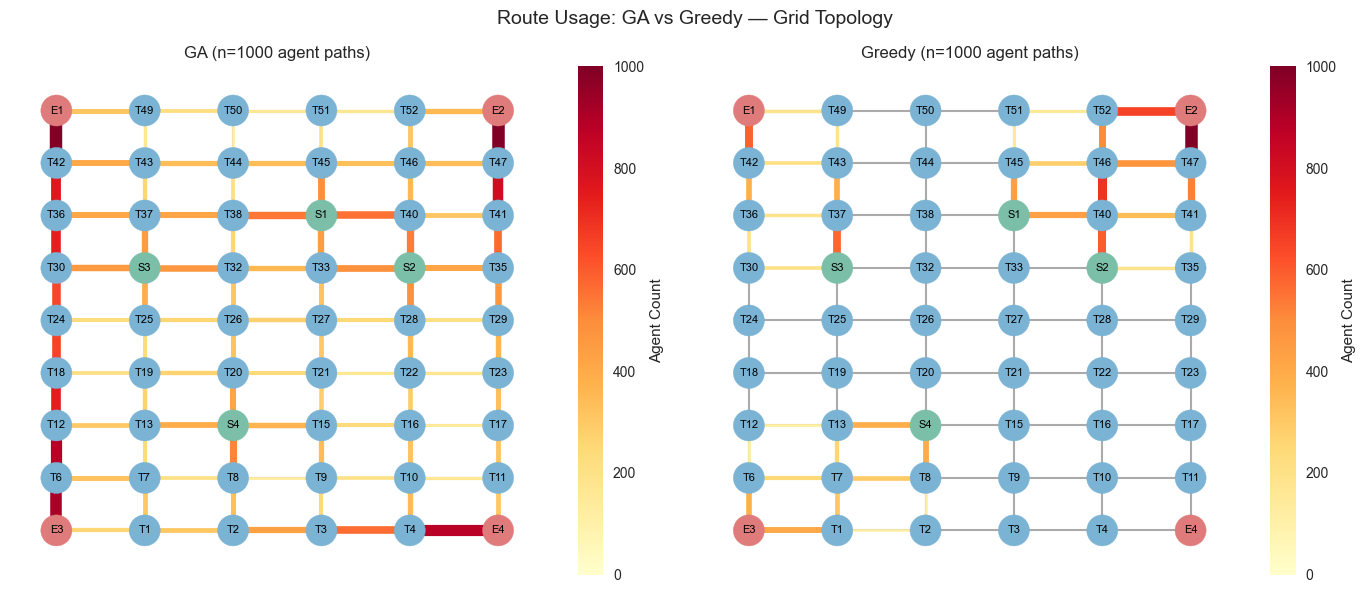

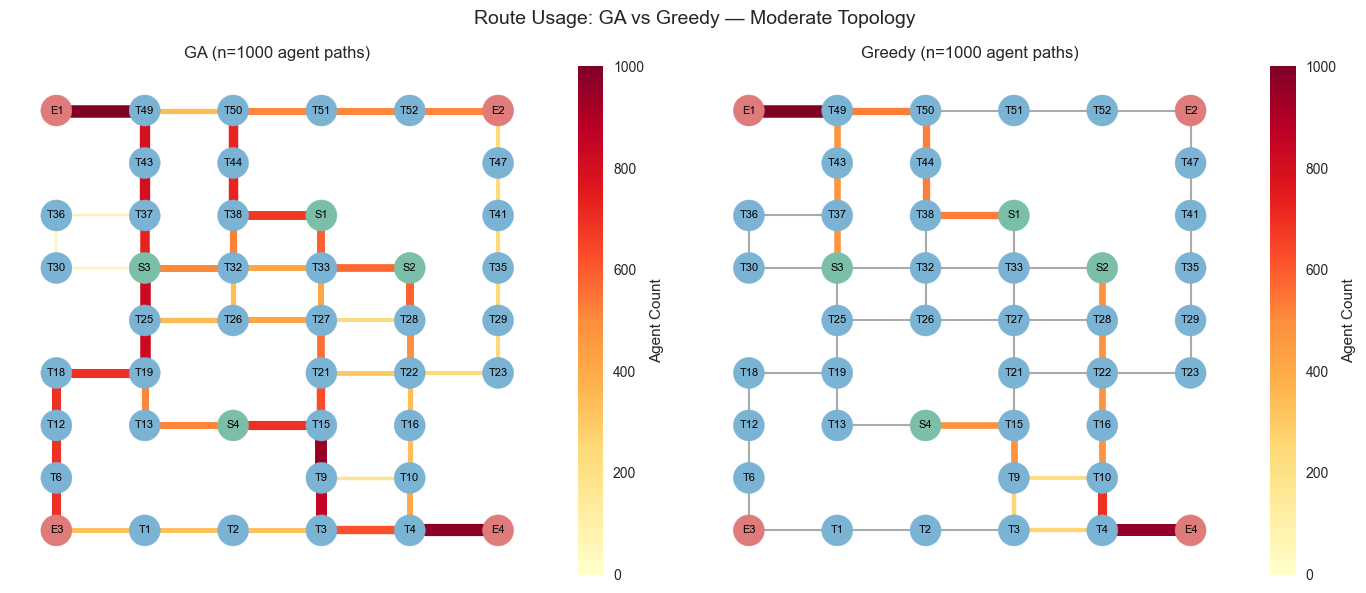

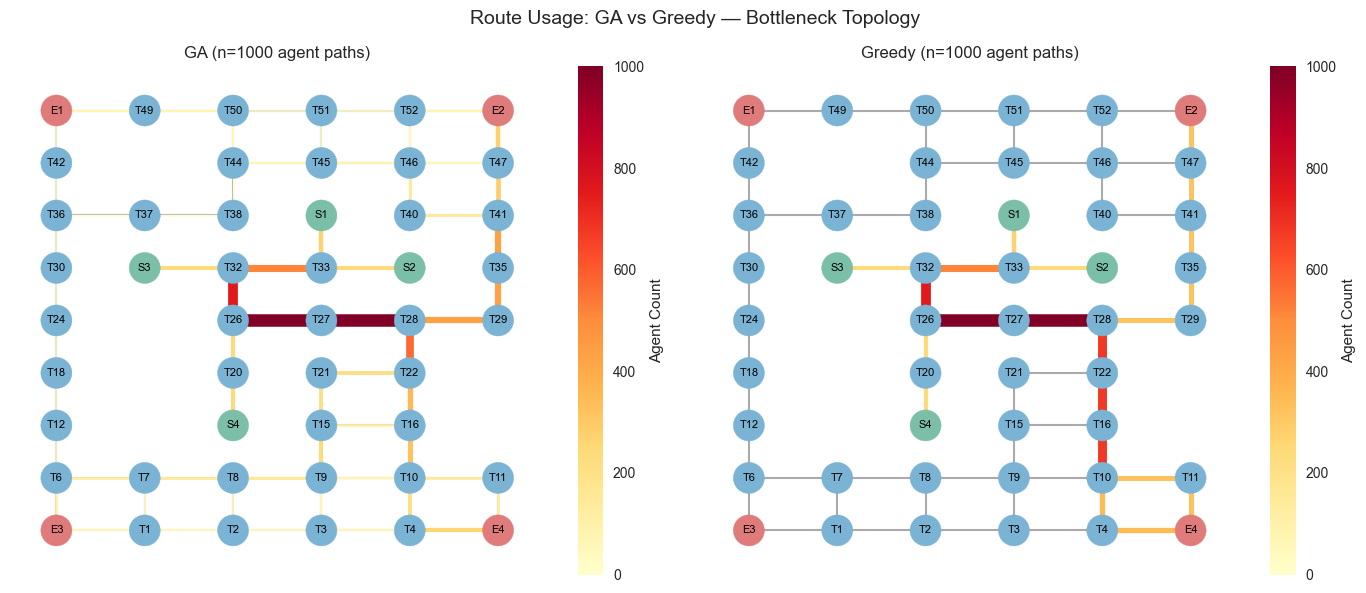

In [ ]:
for city, path in baseline_files.items():
    results = extract_results(path)
    plot_route_comparison_city(city, results, graphs[city], positions[city])

In [80]:
def plot_dispersion_all_cities(baseline_files: dict, n: int = 3) -> None:
    ga_colour = "#378ADD"
    greedy_colour = "#1D9E75"
    cities = list(baseline_files.keys())

    fig, axes = plt.subplots(1, len(cities), figsize=(5 * len(cities), 4))

    def count_agents_within_x(timestep_dict: dict, timestep: int, x: int) -> int:
        count = 0
        for agent_id, positions in timestep_dict.items():
            if timestep >= len(positions):
                continue
            steps_from_start = len(set(positions[:timestep + 1])) - 1
            if steps_from_start <= x:
                count += 1
        return count

    for col, city in enumerate(cities):
        ax = axes[col]
        results = extract_results(baseline_files[city])

        max_t = max(
            len(positions)
            for algorithm in ['ga', 'greedy']
            for ev in results[algorithm]['evals']
            for positions in ev.chromosome.get_timesteps()[0].values()
        )
        timesteps = np.arange(max_t)

        for algorithm, colour, label in [
            ('ga', ga_colour, 'GA'),
            ('greedy', greedy_colour, 'Greedy')
        ]:
            seed_curves = []
            for ev in results[algorithm]['evals']:
                timestep_dict = ev.chromosome.get_timesteps()[0]
                curve = [count_agents_within_x(timestep_dict, t, n) for t in timesteps]
                seed_curves.append(curve)

            seed_curves = np.array(seed_curves)
            mean = seed_curves.mean(axis=0)
            std = seed_curves.std(axis=0)

            ax.plot(timesteps, mean, color=colour, linewidth=1.5, label=label)
            ax.fill_between(timesteps, mean - std, mean + std, alpha=0.15, color=colour)

        ax.set_title(f"{city} Topology")
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Agents within 3 nodes of start" if col == 0 else "")
        ax.grid(True, alpha=0.3)

        if col == 0:
            ax.legend()

    plt.suptitle(f"Agent Dispersion: Agents Within {n} Nodes of Start — GA vs Greedy", fontsize=14)
    plt.tight_layout()
    plt.show()


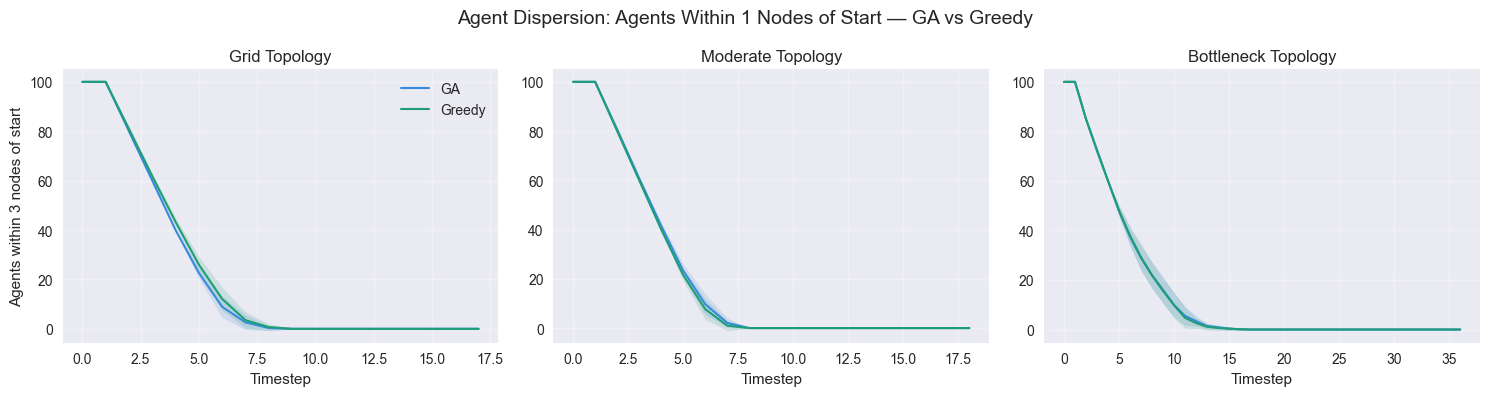

In [81]:
plot_dispersion_all_cities(baseline_files, n=1)

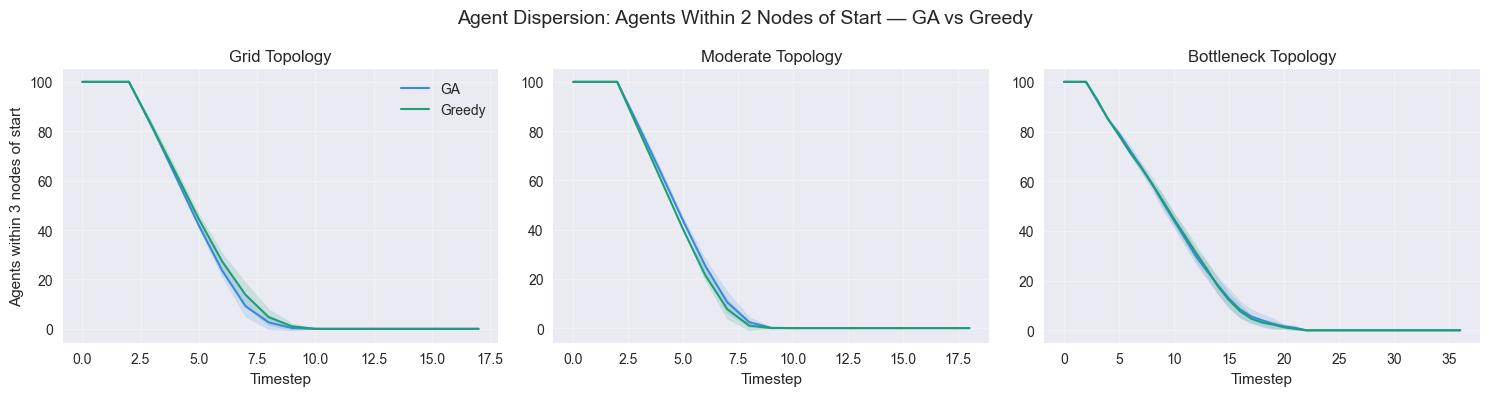

In [82]:
plot_dispersion_all_cities(baseline_files, n=2)

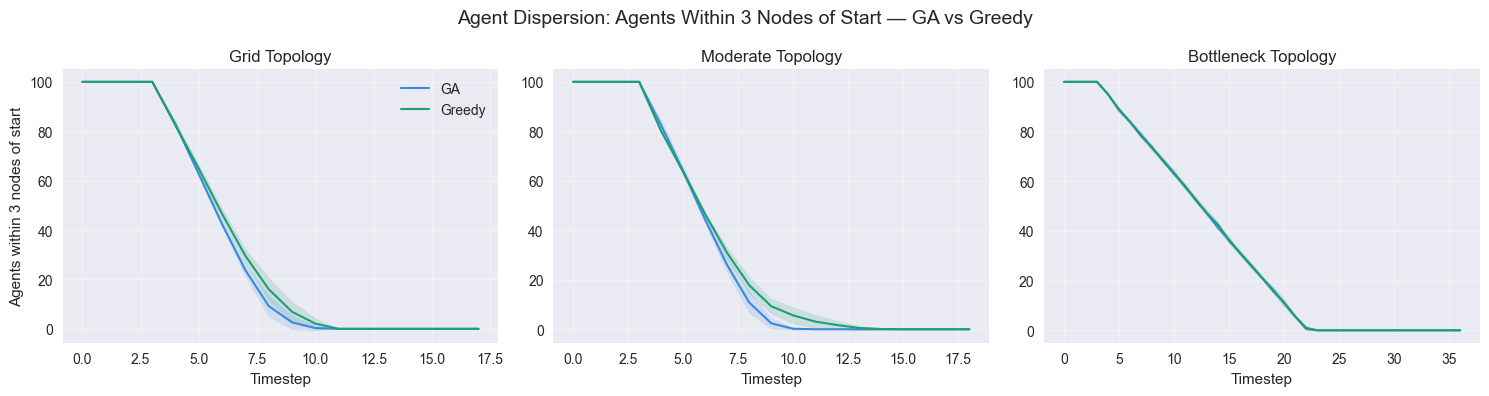

In [83]:
plot_dispersion_all_cities(baseline_files, n=3)

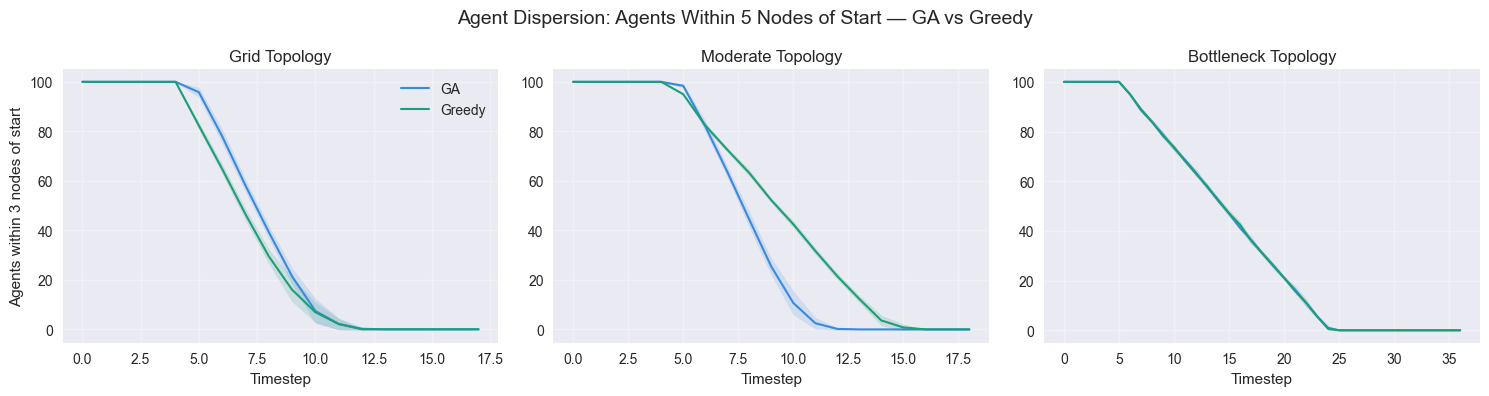

In [ ]:
plot_dispersion_all_cities(baseline_files, n=5)

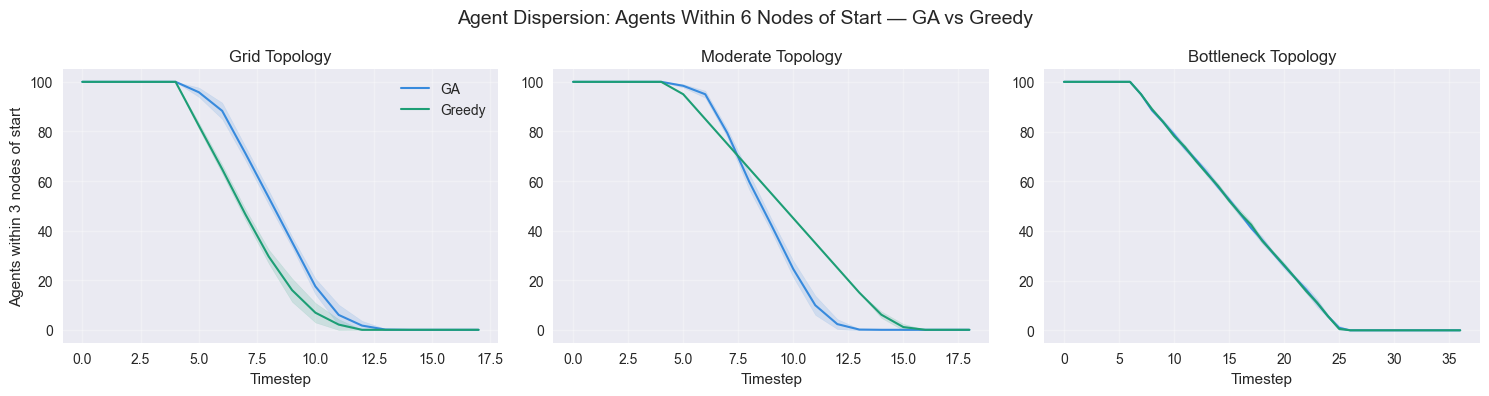

In [85]:
plot_dispersion_all_cities(baseline_files, n=6)